In [2]:
import numpy as np
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
from google.colab import files

uploaded = files.upload()


Saving Restaurant_Reviews.tsv to Restaurant_Reviews.tsv


In [5]:
df = pd.read_csv(
    "Restaurant_Reviews.tsv",
    delimiter="\t",
    quoting=3
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
print("First 5 rows:")
display(df.head())
print("\nDataset Shape:", df.shape)
print("\nColumn Names:", df.columns)
print("\nDataset Information:")
df.info()
print("\nSentiment Distribution:")
print(df["Liked"].value_counts())

First 5 rows:


,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1



Dataset Shape: (1000, 2)

Column Names: Index(['Review', 'Liked'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB

Sentiment Distribution:
Liked
1    500
0    500
Name: count, dtype: int64


In [8]:
nltk.download("stopwords")
print("Stopwords downloaded successfully!")

Stopwords downloaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [9]:
corpus=[]
ps=PorterStemmer()
english_stopwords=set(stopwords.words("english"))
for i in range(len(df)):
  review=re.sub("[^a-zA-Z]","",df["Review"].iloc[i]).lower()
  words=review.split()
  words=[w for w in words if w not in english_stopwords]
  words=[ps.stem(w) for w in words]
  corpus.append("".join(words))
print("Preprocessing completed!")
print("\nFirst 10 processed reviews:")
print(corpus[:10])

Preprocessing completed!

First 10 processed reviews:
['wowlovedthisplac', 'crustisnotgood', 'nottastyandthetexturewasjustnasti', 'stoppedbyduringthelatemaybankholidayoffricksteverecommendationandlovedit', 'theselectiononthemenuwasgreatandsowerethepric', 'nowiamgettingangryandiwantmydamnpho', 'honesltyitdidnttastethatfresh', 'thepotatoeswerelikerubberandyoucouldtelltheyhadbeenmadeupaheadoftimebeingkeptunderawarm', 'thefriesweregreattoo', 'agreattouch']


In [10]:
cv=CountVectorizer(max_features=1500)
X=cv.fit_transform(corpus).toarray()
y=df.iloc[:,1].values
print("Feature matrix shape:",X.shape)
print("Target shape:",y.shape)

Feature matrix shape: (1000, 995)
Target shape: (1000,)


In [11]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20,random_state=0

)
print("Training data shape:",X_train.shape)
print("Testing data shape:",X_test.shape)

Training data shape: (800, 995)
Testing data shape: (200, 995)


In [12]:
model=RandomForestClassifier(n_estimators=35,random_state=42)
model.fit(X_train,y_train)
print("Random Forest model trained successfully")

Random Forest model trained successfully


In [13]:
model_score = model.score(X_test, y_test)
print("Model Accuracy:", round(model_score * 100, 2), "%")
y_pred = model.predict(X_test)
print("Predictions completed!")

Model Accuracy: 48.5 %
Predictions completed!


In [14]:
score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred, zero_division=0)
score3 = recall_score(y_test, y_pred, zero_division=0)
print("---- Scores ----")
print("Accuracy:", round(score1 * 100, 2), "%")
print("Precision:", round(score2, 2))
print("Recall:", round(score3, 2))

---- Scores ----
Accuracy: 48.5 %
Precision: 0.0
Recall: 0.0


In [16]:
print("Classification Report:")
print(classification_report(y_test,y_pred,zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.48      1.00      0.65        97
           1       0.00      0.00      0.00       103

    accuracy                           0.48       200
   macro avg       0.24      0.50      0.33       200
weighted avg       0.24      0.48      0.32       200



Confusion Matrix:
[[ 97   0]
 [103   0]]


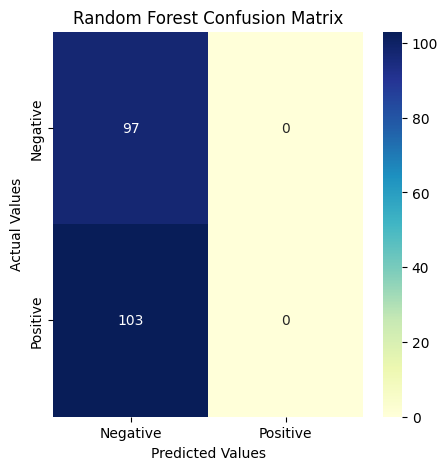

In [18]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(5, 5))
sns.heatmap(
cm,
annot=True,
fmt="d",
cmap="YlGnBu",
xticklabels=["Negative", "Positive"],
yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [20]:
best_accuracy=0
n_estimators_val=5
print("Testing different n_estimators values...\n")
for i in np.arange(1,30,2):
  temp_model=RandomForestClassifier(n_estimators=i,random_state=42)
  temp_model.fit(X_train,y_train)
  temp_pred=temp_model.predict(X_test)
  score=accuracy_score(y_test,temp_pred)
  print("n_estimators=",i,"Accuracy=",round(score*100,2),"%")
  if score>best_accuracy:
    best_accuracy=score
    n_estimators_val=i
print("Best accuracy:",round(best_accuracy*100,2),"%","with n_estimators=",n_estimators_val)

Testing different n_estimators values...

n_estimators= 1 Accuracy= 48.5 %
n_estimators= 3 Accuracy= 48.5 %
n_estimators= 5 Accuracy= 48.5 %
n_estimators= 7 Accuracy= 48.5 %
n_estimators= 9 Accuracy= 48.5 %
n_estimators= 11 Accuracy= 48.5 %
n_estimators= 13 Accuracy= 48.5 %
n_estimators= 15 Accuracy= 48.5 %
n_estimators= 17 Accuracy= 48.5 %
n_estimators= 19 Accuracy= 48.5 %
n_estimators= 21 Accuracy= 48.5 %
n_estimators= 23 Accuracy= 48.5 %
n_estimators= 25 Accuracy= 48.5 %
n_estimators= 27 Accuracy= 48.5 %
n_estimators= 29 Accuracy= 48.5 %
Best accuracy: 48.5 % with n_estimators= 1


In [23]:
model=RandomForestClassifier(n_estimators=n_estimators_val,random_state=42)
model.fit(X_train,y_train)
print("Optimized Random Forest Model:")
print(model)

Optimized Random Forest Model:
RandomForestClassifier(n_estimators=np.int64(1), random_state=42)


In [26]:
def predict_sentiment(sample_review):
    review = re.sub("[^a-zA-Z]", "", sample_review).lower()
    words = review.split()
    words = [w for w in words if w not in english_stopwords]
    words = [ps.stem(w) for w in words]
    review = " ".join(words)
    data = cv.transform([review]).toarray()
    return model.predict(data)[0]
sample_review = "The food is really good here."
prediction = predict_sentiment(sample_review)
print("Review:", sample_review)
if prediction == 1:
   print("This is a POSITIVE review.")
else:
   print("This is a NEGATIVE review!")

Review: The food is really good here.
This is a NEGATIVE review!


In [27]:
sample_review = ("The food was absolutely awful.")
prediction = predict_sentiment(sample_review)
print("Review:", sample_review)
if prediction == 1:
   print("This is a POSITIVE review.")
else:
   print("This is a NEGATIVE review!")

Review: The food was absolutely awful.
This is a NEGATIVE review!


In [28]:
final_predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions, zero_division=0)
recall = recall_score(y_test, final_predictions, zero_division=0)
print("\n==========================================")
print(" FINAL RANDOM FOREST MODEL PERFORMANCE")
print("==========================================")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision, 2))
print("Recall :", round(recall, 2))
print("Best n_estimators:", n_estimators_val)


 FINAL RANDOM FOREST MODEL PERFORMANCE
Accuracy : 48.5 %
Precision: 0.0
Recall : 0.0
Best n_estimators: 1
